1. Importação das bibliotecas e carregamento do dataset

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# Carregamento dos dados do dataset a partir do arquivo flights_100.csv
df = pd.read_csv("flights_100.csv")

2. Exibindo informações chave do dataset

In [85]:
print("=" * 50)
print(f"{'INFORMAÇÕES GERAIS DO DATASET':^50}")
print("=" * 50 + "\n")

print("1. Amostra do dataset:\n" + "-"*50)
print(df.head())  # Exibe as 5 primeiras linhas do dataset (amostra)
print("\n2. Dimensões do dataset:\n" + "-"*50)
print(df.shape) # Exibe as dimensões do dataset
print("\n3. Informações gerais:\n" + "-"*50)
print(df.info())  # Exibe informações gerais do dataset
print("\n4. Descrição geral:\n" + "-"*50)
print(df.describe())  # Exibe uma descrição geral do dataset

          INFORMAÇÕES GERAIS DO DATASET           

1. Amostra do dataset:
--------------------------------------------------
      FL_DATE OP_UNIQUE_CARRIER TAIL_NUM ORIGIN DEST  CRS_DEP_TIME  DEP_DELAY  \
0  2023-01-01              AZUL    N1000    GIG  FOR          1369        7.0   
1  2023-01-02                SW    N1001    BSB  MIA          1986      -42.0   
2  2023-01-03             LATAM    N1002    ORD  REC          1534      -30.0   
3  2023-01-04              AZUL    N1003    JFK  FOR           146      -39.0   
4  2023-01-05                UA    N1004    GIG  SFO          1734      -24.0   

   ARR_DELAY  DISTANCE  
0       32.0      4984  
1      -38.0      4200  
2       21.0      1833  
3       52.0      2352  
4       42.0       710  

2. Dimensões do dataset:
--------------------------------------------------
(100, 9)

3. Informações gerais:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data 

3. Classificando colunas em numéricas ou categóricas e apurando valores ausentes

In [71]:
print("=" * 50)
print(f"{'CLASSIFICAÇÃO DOS DADOS':^50}")
print("=" * 50 + "\n")

# Classificando colunas entre numéricas e categóricas
numeric_cols = df.select_dtypes(include=[np.number]).columns  # Seleciona colunas numéricas
categorical_cols = df.select_dtypes(include="object").columns # Seleciona colunas categóricas

# Valores ausentes
print("Tipo de dados:")
print(df.dtypes.value_counts())

missing = df.isnull().sum()
print(f"\nValores ausentes: {missing.sum()}")

             CLASSIFICAÇÃO DOS DADOS              

Tipo de dados:
object     5
int64      2
float64    2
Name: count, dtype: int64

Valores ausentes: 20


4. Gerando estatísticas descritivas dos dados

In [72]:
print("=" * 50)
print(f"{'ESTATÍSTICAS DESCRITIVAS':^50}")
print("=" * 50 + "\n")

# Média, mediana, desvio padrão e amplitude das colunas numéricas
for col in numeric_cols:
  media = df[col].mean()
  mediana = df[col].median()
  amplitude = df[col].max() - df[col].min()
  desvio = df[col].std()

  print(f"Coluna: {col}:\n" + "-"*50)
  print(f"Média: {media:.2f}")
  print(f"Mediana: {mediana:.2f}")
  print(f"Amplitude: {amplitude:.2f}")
  print(f"Desvio: {desvio:.2f}")
  print() # Quebra uma linha para melhor visualização dos dados

             ESTATÍSTICAS DESCRITIVAS             

Coluna: CRS_DEP_TIME:
--------------------------------------------------
Média: 1242.93
Mediana: 1230.50
Amplitude: 2315.00
Desvio: 686.19

Coluna: DEP_DELAY:
--------------------------------------------------
Média: 9.07
Mediana: 7.00
Amplitude: 163.00
Desvio: 33.68

Coluna: ARR_DELAY:
--------------------------------------------------
Média: 7.69
Mediana: 6.00
Amplitude: 193.00
Desvio: 39.10

Coluna: DISTANCE:
--------------------------------------------------
Média: 2897.62
Mediana: 2940.00
Amplitude: 4647.00
Desvio: 1420.35



5. Inspecionando a variável-alvo (atraso)

In [73]:
# Atrasos de partida > 15 min
atrasos_significativos = (df["DEP_DELAY"] > 15).astype(int)

6. Gráficos: Histograma de atrasos e Heatmap de correlações

               GRÁFICOS DESCRITIVOS               



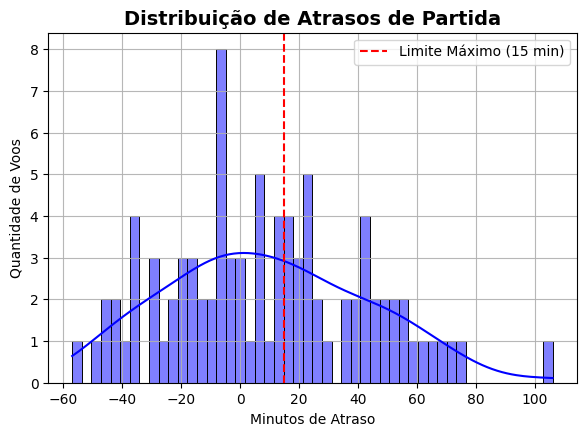

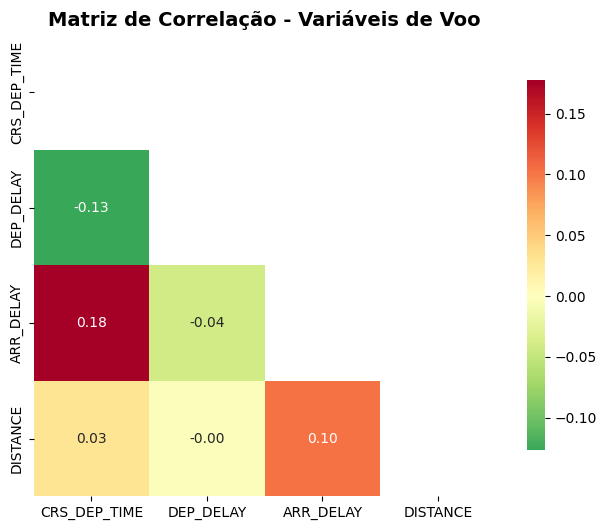

In [84]:
print("=" * 50)
print(f"{'GRÁFICOS DESCRITIVOS':^50}")
print("=" * 50 + "\n")

# Histograma da distribuição de atrasos na partida
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)

sns.histplot(df["DEP_DELAY"], bins=50, kde=True, color="blue")
plt.title("Distribuição de Atrasos de Partida", fontsize=14, fontweight="bold")
plt.xlabel("Minutos de Atraso")
plt.ylabel("Quantidade de Voos")

# Linha vertical indicanddo o limite de atraso (15 min)
plt.axvline(15, color="red", linestyle="--", label="Limite Máximo (15 min)")
plt.legend()
plt.grid(True, alpha=0.9)

# Heatmap das correlações
correlation_matrix = df[numeric_cols].corr() # Matriz de correlação das colunas numéricas

plt.figure(figsize=(8, 6), alpha=0.9)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="RdYlGn_r",
            center=0, square=True, fmt=".2f", cbar_kws={"shrink": .8})
plt.title("Matriz de Correlação - Variáveis de Voo", fontsize=14, fontweight="bold")
plt.show()

7. Registro de anomalias e hipóteses para tratamentos futuros

- A coluna CRS_DEP_TIME, apesar de aparecer no `df.info()` como uma coluna numérica, traz dados relacionados à hora da viagem. Esses dados deveriam ser tratados antes de serem utilizados nas estatísticas ou gráficos
- Uma suposta anomalia pode ser vista no gráfico de distribuição de atrasos, provavelmente os dados deveriam ser tratados de uma melhor forma para evitar comportamentos anômalos